# Final Dataset Construction

In [1]:
import pandas as pd
from tqdm import tqdm
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors

import requests
import json
from urllib.parse import urlencode
import orjson

import warnings
warnings.filterwarnings("ignore")

In [2]:
BASE_URL = "https://api.openalex.org/works"

selected_fields = ["doi", "publication_year", "language", "indexed_in", "primary_location", "best_oa_location", "open_access", "authorships", 
                   "corresponding_author_ids", "corresponding_institution_ids", "apc_list", "apc_paid", "cited_by_count", "primary_topic", "awards", "funders"]

batch_size = 100


interest_fields = ['doi', 'publication_year', 'language', 'authorships', 'primary_location', 'open_access', 'apc_paid']
keys = ['doi', 'publication_year', 'language', 'issn_l', 'oa_status', 'apc_paid', 'corresponding', 'countries']


def fetch_by_ids(id_list):
    # Normalize IDs to a string separated by |
    doi_filter = "doi:" + "|".join(id_list)

    filters = [
        doi_filter,
        "indexed_in:crossref",
        "type:article|review",
    ]

    params = {
        "filter": ",".join(filters),
        "select": ",".join(selected_fields),
        "per_page": 200
    }

    url = f"{BASE_URL}?{urlencode(params)}"
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        data = r.json()
        return data.get("results", [])
    except (requests.exceptions.JSONDecodeError, requests.exceptions.RequestException) as e:
        print("Request error or JSON decode error:", e)
        return []  # ← always return an empty list on failure

def extract_dois_from_jsonl(file_path):
    records = []
    with open(file_path) as f:
        for line in f:
            rec = orjson.loads(line)
            if not rec.get("doi"): # Skip records without DOI
                continue
            filtered = {k: rec.get(k) for k in interest_fields} # Keep only the fields we care about

            # Extract journal and publisher from best_oa_location
            pl = filtered.get("primary_location") or {}
            source = pl.get("source") or {}
            filtered["issn_l"] = source.get("issn_l")

            # Extract institution types and number of authors
            authorships = filtered.get("authorships") or []
            filtered["corresponding"] = [auth.get("is_corresponding") for auth in authorships]
            filtered["countries"] = [auth.get("countries") for auth in authorships]
                
            o_a = filtered.get("open_access") or {}
            filtered["oa_status"] = o_a.get("oa_status")

            records.append({k: filtered.get(k) for k in keys})
    return records

def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

def select_CA(ca_positions, n_authors):
    if not ca_positions:  # no CA, just in case
        return None, None
    if 0 in ca_positions:
        return 0, 'First'
    elif (n_authors - 1) in ca_positions:
        return n_authors - 1, 'Last'
    else:
        return ca_positions[0], 'Middle'
    
def priority(row):
    if pd.notna(row['APC_Accounting_Value']):
        return row['APC_Accounting_Value'], 'APC_Accounting_Value'
    if pd.notna(row['euro']):
        return row['euro'], 'Open APC'
    if pd.notna(row['median']):
        return row['median'], 'Open APC Median'
    else:
        return row['value_usd_to_eur'], 'APC_paid'
    
def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []
        
def price(row):
    if 0 in row['french_position']:
        return row['First_pct'] * row['price_var']
    if row['len'] - 1 in row['french_position']:
        return row['Last_pct'] * row['price_var']
    else:
        return len(row['french_position']) * row['price_var'] * row['len'] / (row['len'] - 2)

## Initial Download Processing

In [3]:
interest = ['doi', 'publication_year', 'language', 'issn_l', 'oa_status', 'apc_paid', 'corresponding', 'countries']

df_oa = []
for year in tqdm(range(2013, 2025)):
    df_oa_tmp = pd.read_csv(f'../data/interim/oa_initial_{year}_trial.csv').drop(columns = 'Unnamed: 0')[interest] # "trial" IN ORDER TO HAVE PRIMARY LOCATION AND NOT BEST OA LOCATION WHICH IS MOSTLY EMPTY
    df_oa_tmp['doi'] = df_oa_tmp['doi'].apply(lambda x: x[16:].lower())
    df_oa.append(df_oa_tmp)
df_oa = pd.concat((df_oa), ignore_index = True)
df_oa

  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:23<00:00,  1.95s/it]


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries
0,10.1016/j.cell.2013.05.039,2013,en,0092-8674,bronze,NaN,"[False, False, False, True, False]","[['ES'], ['ES'], ['DE', 'GB'], ['ES'], ['FR']]"
1,10.1051/0004-6361/201322068,2013,en,0004-6361,bronze,NaN,"[False, False, False, False, False, False, Fal...","[['DE'], ['US'], ['FR', 'US'], ['FR', 'US'], [..."
2,10.2458/azu_js_rc.55.16947,2013,en,0033-8222,bronze,NaN,"[True, False, False, False, False, False, Fals...","[['GB'], ['FR'], ['GB'], ['US'], ['GB'], ['GB'..."
3,10.1038/nature12477,2013,en,0028-0836,bronze,NaN,"[False, False, False, False, False, False, Fal...","[['GB'], ['GB'], ['GB'], ['CA'], ['GB'], ['GB'..."
4,10.1097/ccm.0b013e31827e83af,2013,en,0090-3493,closed,NaN,"[False, False, False, False, False, False, Fal...","[['US'], ['US'], ['GB'], ['FR'], ['DE'], ['US'..."
...,...,...,...,...,...,...,...,...
1545016,10.1007/s10499-025-02358-1,2024,en,0967-6120,closed,NaN,"[True, False, False, False, False, False, Fals...","[['VN'], ['HK'], ['VN'], ['CN'], ['TH'], ['VN'..."
1545017,10.37665/remcajp40761,2024,NaN,3068-0751,closed,NaN,[True],[['FR']]
1545018,10.4000/15ara,2024,NaN,0765-0752,diamond,NaN,"[True, False, False, False]","[['FR'], ['GB', 'US'], [], []]"
1545019,10.4000/11ndt,2024,fr,1954-3670,bronze,NaN,[True],[['FR']]


## Integrate BSO

To increment the perimeter

In [ ]:
interest = ['doi', 'bso_country_corrected', 'genre', 'openalex_id', 'has_fr_corresponding']
records = []
for year in tqdm(range(2013, 2025)):
    with open(f"../data/external/BSO/bso-publications-latest_split_{year}_enriched.jsonl", "rb") as f:
        for line in f:
            rec = orjson.loads(line)
            filtered = {k: rec.get(k) for k in interest} # Keep only the fields we care about
            if not filtered.get("doi"): # Skip records without DOI
                continue
            if 'fr' not in (filtered.get('bso_country_corrected') if isinstance(filtered.get('bso_country_corrected'), list) else [filtered.get('bso_country_corrected')] if filtered.get('bso_country_corrected') else []):
                continue
            if any(g in (filtered['genre'] if isinstance(filtered['genre'], list) else [filtered['genre']]) for g in ['journal-article', 'proceedings']):
                records.append(filtered)
                continue
   
df = pd.DataFrame(records)
df.to_csv('../data/interim/bso.csv', index = False)
df

In [4]:
df = pd.read_csv('../data/interim/bso.csv')
df['doi'] = df['doi'].apply(lambda x: x.lower())

df_oa_comb = df_oa.merge(df, on = 'doi', how = 'left')
df_oa_comb['BSO'] = df_oa_comb['openalex_id'].notna()
df_oa_comb = df_oa_comb.drop(columns = ['bso_country_corrected', 'genre', 'openalex_id'])
df_oa_comb

,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO
0,10.1016/j.cell.2013.05.039,2013,en,0092-8674,bronze,NaN,"[False, False, False, True, False]","[['ES'], ['ES'], ['DE', 'GB'], ['ES'], ['FR']]",False,True
1,10.1051/0004-6361/201322068,2013,en,0004-6361,bronze,NaN,"[False, False, False, False, False, False, Fal...","[['DE'], ['US'], ['FR', 'US'], ['FR', 'US'], [...",False,True
2,10.2458/azu_js_rc.55.16947,2013,en,0033-8222,bronze,NaN,"[True, False, False, False, False, False, Fals...","[['GB'], ['FR'], ['GB'], ['US'], ['GB'], ['GB'...",False,True
3,10.1038/nature12477,2013,en,0028-0836,bronze,NaN,"[False, False, False, False, False, False, Fal...","[['GB'], ['GB'], ['GB'], ['CA'], ['GB'], ['GB'...",False,True
4,10.1097/ccm.0b013e31827e83af,2013,en,0090-3493,closed,NaN,"[False, False, False, False, False, False, Fal...","[['US'], ['US'], ['GB'], ['FR'], ['DE'], ['US'...",NaN,False
...,...,...,...,...,...,...,...,...,...,...
1545077,10.1007/s10499-025-02358-1,2024,en,0967-6120,closed,NaN,"[True, False, False, False, False, False, Fals...","[['VN'], ['HK'], ['VN'], ['CN'], ['TH'], ['VN'...",NaN,False
1545078,10.37665/remcajp40761,2024,NaN,3068-0751,closed,NaN,[True],[['FR']],NaN,False
1545079,10.4000/15ara,2024,NaN,0765-0752,diamond,NaN,"[True, False, False, False]","[['FR'], ['GB', 'US'], [], []]",NaN,False
1545080,10.4000/11ndt,2024,fr,1954-3670,bronze,NaN,[True],[['FR']],NaN,False


### Download the missing

Most of the dois are not articles or reviews

In [5]:
df_bso_oa = df[~df.openalex_id.isna()]
missing = df_bso_oa[~df_bso_oa.doi.str.lower().isin(df_oa_comb.doi)].doi.unique()

all_fetched = []
for i in tqdm(range(0, len(missing), batch_size)):
    batch = missing[i:i+batch_size]
    results = fetch_by_ids(batch)
    all_fetched.extend(results)
    
output_file = "../data/interim/FranceInitialAPI/openalex_missing.jsonl"
with open(output_file, "w", encoding="utf-8") as f:
    for w in all_fetched:
        f.write(json.dumps(w) + "\n")

print(f"Saved {len(all_fetched)} records to {output_file}")

100%|██████████| 1076/1076 [09:35<00:00,  1.87it/s]


Saved 12145 records to ../data/interim/FranceInitialAPI/openalex_missing.jsonl


In [8]:
df_oa_missing

,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries
0,10.1088/0004-637x/772/1/7,2013,en,0004-637X,bronze,None,"[True, False, False, False]","[[], [], [], []]"
1,10.1016/j.difgeo.2013.06.001,2013,en,0926-2245,green,None,"[True, False]","[[], []]"
2,10.1016/j.datak.2013.06.002,2013,en,0169-023X,green,None,"[True, False, False, False]","[[], [], [], []]"
3,10.1209/0295-5075/101/30006,2013,en,0295-5075,green,None,"[True, False]","[[], []]"
4,10.1016/j.bjp.2013.12.018,2013,en,1389-1286,bronze,None,"[True, False]","[[FR], [FR]]"
...,...,...,...,...,...,...,...,...
12119,10.1007/s00028-024-00946-x,2024,en,1424-3199,green,None,[True],[[FR]]
12120,10.1016/j.ymssp.2024.111486,2024,en,0888-3270,hybrid,"{'value': 4830, 'currency': 'USD', 'value_usd'...","[True, False, False, False, False]","[[FR], [FR], [FR], [FR], [FR]]"
12121,10.1016/j.finel.2024.104163,2024,en,0168-874X,green,None,"[True, False, False]","[[FR], [FR], [FR]]"
12122,10.54563/cahiers-duras.519,2024,fr,2804-7338,hybrid,None,[True],[[FR]]


In [9]:
records_tmp = extract_dois_from_jsonl(f"../data/interim/FranceInitialAPI/openalex_missing.jsonl")

df_oa_missing = pd.DataFrame(records_tmp)
df_oa_missing = df_oa_missing[(df_oa_missing['publication_year'] >= 2013) & (df_oa_missing['publication_year'] <= 2024)].reset_index(drop = True)
df_oa_missing['doi'] = df_oa_missing['doi'].apply(lambda x: x[16::].lower())
df_oa_missing = df_oa_missing.merge(df[['doi', 'has_fr_corresponding']], on = 'doi', how = 'left')
print(df_oa_missing.apply(lambda row: True if isinstance(row['countries'], list) and all(len(sub) == 0 for sub in row['countries']) and row['has_fr_corresponding'] == True else False, axis = 1).sum())
df_oa_missing["countries"] = df_oa_missing.apply(lambda row: [['FR'] for _ in row['countries']] if isinstance(row['countries'], list) and all(len(sub) == 0 for sub in row['countries']) and row['has_fr_corresponding'] == True else row['countries'], axis = 1) 
# IN ORDER TO EFFECTIVELY INCORPORATE FROM BSO (I "INVENT" THAT EVERYTHING IS FRENCH) IF has_fr_corresponding == true
df_oa_missing = df_oa_missing.drop(columns = 'has_fr_corresponding')
df_oa_missing['Added'] = 'BSO'
df_oa_missing

2050


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,Added
0,10.1088/0004-637x/772/1/7,2013,en,0004-637X,bronze,None,"[True, False, False, False]","[[], [], [], []]",BSO
1,10.1016/j.difgeo.2013.06.001,2013,en,0926-2245,green,None,"[True, False]","[[], []]",BSO
2,10.1016/j.datak.2013.06.002,2013,en,0169-023X,green,None,"[True, False, False, False]","[[], [], [], []]",BSO
3,10.1209/0295-5075/101/30006,2013,en,0295-5075,green,None,"[True, False]","[[], []]",BSO
4,10.1016/j.bjp.2013.12.018,2013,en,1389-1286,bronze,None,"[True, False]","[[FR], [FR]]",BSO
...,...,...,...,...,...,...,...,...,...
12119,10.1007/s00028-024-00946-x,2024,en,1424-3199,green,None,[True],[[FR]],BSO
12120,10.1016/j.ymssp.2024.111486,2024,en,0888-3270,hybrid,"{'value': 4830, 'currency': 'USD', 'value_usd'...","[True, False, False, False, False]","[[FR], [FR], [FR], [FR], [FR]]",BSO
12121,10.1016/j.finel.2024.104163,2024,en,0168-874X,green,None,"[True, False, False]","[[FR], [FR], [FR]]",BSO
12122,10.54563/cahiers-duras.519,2024,fr,2804-7338,hybrid,None,[True],[[FR]],BSO


In [10]:
df_oa_comb_2 = df_oa_missing.merge(df, on = 'doi', how = 'left')
df_oa_comb_2['BSO'] = df_oa_comb_2['openalex_id'].notna()
df_oa_comb_2 = df_oa_comb_2.drop(columns = ['bso_country_corrected', 'genre', 'openalex_id'])

df_tmp = pd.concat((df_oa_comb, df_oa_comb_2)).reset_index(drop = True)
df_tmp

,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,Added
0,10.1016/j.cell.2013.05.039,2013,en,0092-8674,bronze,NaN,"[False, False, False, True, False]","[['ES'], ['ES'], ['DE', 'GB'], ['ES'], ['FR']]",False,True,NaN
1,10.1051/0004-6361/201322068,2013,en,0004-6361,bronze,NaN,"[False, False, False, False, False, False, Fal...","[['DE'], ['US'], ['FR', 'US'], ['FR', 'US'], [...",False,True,NaN
2,10.2458/azu_js_rc.55.16947,2013,en,0033-8222,bronze,NaN,"[True, False, False, False, False, False, Fals...","[['GB'], ['FR'], ['GB'], ['US'], ['GB'], ['GB'...",False,True,NaN
3,10.1038/nature12477,2013,en,0028-0836,bronze,NaN,"[False, False, False, False, False, False, Fal...","[['GB'], ['GB'], ['GB'], ['CA'], ['GB'], ['GB'...",False,True,NaN
4,10.1097/ccm.0b013e31827e83af,2013,en,0090-3493,closed,NaN,"[False, False, False, False, False, False, Fal...","[['US'], ['US'], ['GB'], ['FR'], ['DE'], ['US'...",NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1557201,10.1007/s00028-024-00946-x,2024,en,1424-3199,green,None,[True],[[FR]],True,True,BSO
1557202,10.1016/j.ymssp.2024.111486,2024,en,0888-3270,hybrid,"{'value': 4830, 'currency': 'USD', 'value_usd'...","[True, False, False, False, False]","[[FR], [FR], [FR], [FR], [FR]]",False,True,BSO
1557203,10.1016/j.finel.2024.104163,2024,en,0168-874X,green,None,"[True, False, False]","[[FR], [FR], [FR]]",False,True,BSO
1557204,10.54563/cahiers-duras.519,2024,fr,2804-7338,hybrid,None,[True],[[FR]],True,True,BSO


### Check if not in Oa is not in OA

In [7]:
missing = df[df.openalex_id.isna()].doi.unique()
print(len(missing))
all_fetched = []
for i in tqdm(range(0, len(missing), batch_size)):
    batch = missing[i:i+batch_size]
    results = fetch_by_ids(batch)
    all_fetched.extend(results)

output_file = "../data/interim/FranceInitialAPI/not_openalex.jsonl"
with open(output_file, "w", encoding="utf-8") as f:
    for w in all_fetched:
        f.write(json.dumps(w) + "\n")

print(f"Saved {len(all_fetched)} records to {output_file}")

292324


100%|██████████| 2924/2924 [46:27<00:00,  1.05it/s]  


Saved 280445 records to ../data/interim/FranceInitialAPI/not_openalex.jsonl


In [11]:
records_tmp = extract_dois_from_jsonl(f"../data/interim/FranceInitialAPI/not_openalex.jsonl")
df_not_oa = pd.DataFrame(records_tmp)
df_not_oa = df_not_oa[(df_not_oa['publication_year'] >= 2013) & (df_not_oa['publication_year'] <= 2024)].reset_index(drop = True)
df_not_oa['doi'] = df_not_oa['doi'].apply(lambda x: x[16::].lower())
df_not_oa = df_not_oa.merge(df[['doi', 'has_fr_corresponding']], on = 'doi', how = 'left')
print(df_not_oa.apply(lambda row: True if isinstance(row['countries'], list) and all(len(sub) == 0 for sub in row['countries']) and row['has_fr_corresponding'] == True else False, axis = 1).sum())
df_not_oa["countries"] = df_not_oa.apply(lambda row: [['FR'] for _ in row['countries']] if isinstance(row['countries'], list) and all(len(sub) == 0 for sub in row['countries']) and row['has_fr_corresponding'] == True else row['countries'], axis = 1) 
# IN ORDER TO EFFECTIVELY INCORPORATE FROM BSO (I "INVENT" THAT EVERYTHING IS FRENCH) IF has_fr_corresponding == true
df_not_oa = df_not_oa.drop(columns = 'has_fr_corresponding')
df_not_oa['Added'] = 'BSO'
df_not_oa

71678


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,Added
0,10.1056/nejmoa1113697,2013,en,0028-4793,bronze,None,"[True, False, False, False, False, False, Fals...","[[CA, SE], [CA], [GB], [DE], [SE], [NL], [NO],...",BSO
1,10.1016/s0140-6736(12)62191-6,2013,en,0140-6736,closed,None,"[True, False, False, False, False, False, Fals...","[[CH], [GB], [AU], [US], [CH], [CH], [PK], [US...",BSO
2,10.1038/nature11913,2013,en,0028-0836,closed,None,"[True, False, False, False, False, False, False]","[[CH], [CH], [CH], [CH], [CH], [CH], [CH]]",BSO
3,10.3389/fimmu.2013.00297,2013,en,1664-3224,gold,"{'value': 1105, 'currency': 'EUR', 'value_usd'...","[True, False, False]","[[], [DE], [DE]]",BSO
4,10.1162/coli_a_00178,2013,en,0891-2017,bronze,None,[True],[[GB]],BSO
...,...,...,...,...,...,...,...,...,...
280422,10.4000/11z8h,2024,fr,2107-027X,hybrid,None,[True],[[US]],BSO
280423,10.3917/regar.063.0105,2024,fr,0988-6982,bronze,None,[True],[[FR]],BSO
280424,10.1016/j.optcom.2024.130895,2024,en,0030-4018,closed,None,"[True, False]","[[FR], [FR]]",BSO
280425,10.62229/aubllrlxxi/22/2,2024,en,1220-0271,bronze,None,"[True, False]","[[FR], []]",BSO


In [12]:
df_not_oa['BSO'] = True
df_final = pd.concat((df_tmp, df_not_oa)).drop_duplicates('doi').reset_index(drop = True)
df_final

,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,Added
0,10.1016/j.cell.2013.05.039,2013,en,0092-8674,bronze,NaN,"[False, False, False, True, False]","[['ES'], ['ES'], ['DE', 'GB'], ['ES'], ['FR']]",False,True,NaN
1,10.1051/0004-6361/201322068,2013,en,0004-6361,bronze,NaN,"[False, False, False, False, False, False, Fal...","[['DE'], ['US'], ['FR', 'US'], ['FR', 'US'], [...",False,True,NaN
2,10.2458/azu_js_rc.55.16947,2013,en,0033-8222,bronze,NaN,"[True, False, False, False, False, False, Fals...","[['GB'], ['FR'], ['GB'], ['US'], ['GB'], ['GB'...",False,True,NaN
3,10.1038/nature12477,2013,en,0028-0836,bronze,NaN,"[False, False, False, False, False, False, Fal...","[['GB'], ['GB'], ['GB'], ['CA'], ['GB'], ['GB'...",False,True,NaN
4,10.1097/ccm.0b013e31827e83af,2013,en,0090-3493,closed,NaN,"[False, False, False, False, False, False, Fal...","[['US'], ['US'], ['GB'], ['FR'], ['DE'], ['US'...",NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1833446,10.4000/11z8h,2024,fr,2107-027X,hybrid,None,[True],[[US]],NaN,True,BSO
1833447,10.3917/regar.063.0105,2024,fr,0988-6982,bronze,None,[True],[[FR]],NaN,True,BSO
1833448,10.1016/j.optcom.2024.130895,2024,en,0030-4018,closed,None,"[True, False]","[[FR], [FR]]",NaN,True,BSO
1833449,10.62229/aubllrlxxi/22/2,2024,en,1220-0271,bronze,None,"[True, False]","[[FR], []]",NaN,True,BSO


## Integreta NA

In [ ]:
interest = ['DOI', 'Has_Discount', 'USD_EUR_Yearly_Avg_Conv_Rate', 'Status_Source', 'Deal_Name', 'Deal_Type', 'Year_Publication', 'Eligible_Deal', 'APC_Accounting_Value']

df_na = pd.read_csv('../data/processed/all_couperin.csv', sep = ',', engine = 'python', on_bad_lines="skip")[interest]
print(len(df_na))
df_na = df_na[(df_na.Year_Publication != 'TRUE') & (df_na.Year_Publication.notna())].reset_index(drop = True) # ERROR IN THÈODORE FILE
print(len(df_na))
df_na['Year_Publication'] = df_na['Year_Publication'].astype(int)
df_na['DOI'] = df_na['DOI'].apply(lambda x: x.lower())
df_na = df_na[(df_na.Year_Publication >= 2013) & (df_na.Year_Publication <= 2024)].reset_index(drop = True)
df_na = df_na.drop(columns = 'Year_Publication').rename(columns = {'DOI':'doi'})
df_na['Is_Couperin'] = True
print(len(df_na))
df_na

148478
148019
132860


,doi,Has_Discount,USD_EUR_Yearly_Avg_Conv_Rate,Status_Source,Deal_Name,Deal_Type,Eligible_Deal,APC_Accounting_Value,Is_Couperin
0,10.1186/s12859-022-05048-4,NaN,0.9496,NaN,NaN,NaN,NaN,2190.0,True
1,10.1016/j.rmed.2024.107606,NaN,0.9228,Accepted,Elsevier II,Read & Publish,True,0.0,True
2,10.1186/s12890-019-0851-5,NaN,0.8932,NaN,NaN,NaN,NaN,2190.0,True
3,10.1186/s12931-020-01572-0,NaN,0.8756,NaN,NaN,NaN,NaN,2490.0,True
4,10.1007/s11238-018-9668-6,NaN,0.8470,NaN,NaN,NaN,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...
132855,10.5194/tc-17-5241-2023,NaN,0.9280,NaN,NaN,NaN,NaN,1078.0,True
132856,10.5194/wes-8-1319-2023,NaN,0.9280,NaN,NaN,NaN,NaN,1449.0,True
132857,10.5194/wes-8-141-2023,NaN,0.9280,NaN,NaN,NaN,NaN,483.0,True
132858,10.5194/wes-8-1711-2023,NaN,0.9280,NaN,NaN,NaN,NaN,828.0,True


**Download the missing**

In [11]:
missing = (df_na[~df_na.doi.isin(df_final.doi)].doi.dropna().str.strip().str.lower().unique())
print(len(missing))
all_fetched = []
for i in tqdm(range(0, len(missing), batch_size)):
    batch = missing[i:i+batch_size]
    results = fetch_by_ids(batch)
    all_fetched.extend(results)
    
output_file = "../data/interim/FranceInitialAPI/openalex_na_missing.jsonl"
with open(output_file, "w", encoding="utf-8") as f:
    for w in all_fetched:
        f.write(json.dumps(w) + "\n")

print(f"Saved {len(all_fetched)} records to {output_file}")

6183


100%|██████████| 62/62 [00:40<00:00,  1.54it/s]

Saved 2488 records to ../data/interim/FranceInitialAPI/openalex_na_missing.jsonl


In [15]:
records_tmp = extract_dois_from_jsonl(f"../data/interim/FranceInitialAPI/openalex_na_missing.jsonl")
df_na_not_oa = pd.DataFrame(records_tmp)
df_na_not_oa = df_na_not_oa[(df_na_not_oa['publication_year'] >= 2013) & (df_na_not_oa['publication_year'] <= 2024)].reset_index(drop = True)
df_na_not_oa["countries"] = df_na_not_oa["countries"].apply(lambda lst: [['FR'] for _ in lst] if isinstance(lst, list) and all(len(sub) == 0 for sub in lst) else lst) # IN ORDER TO EFFECTIVELY INCORPORATE FROM BSO (I INVENT THAT EVERYTHING IS FRENCH)
df_na_not_oa['doi'] = df_na_not_oa['doi'].apply(lambda x: x[16::].lower())
df_na_not_oa['Added'] = 'Couperin'
df_na_not_oa

,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,Added
0,10.1111/joms.12928,2023,en,0022-2380,bronze,None,"[True, False]","[[CA, FR], [US]]",Couperin
1,10.1080/02678292.2020.1825842,2020,en,0267-8292,bronze,None,"[True, False, False, False]","[[DE], [DE], [DE], [DE]]",Couperin
2,10.1016/j.optmat.2024.116205,2024,en,0925-3467,hybrid,"{'value': 2420, 'currency': 'USD', 'value_usd'...","[False, False, False, True, False, True, True]","[[AZ, JO], [IN], [SA], [FR, KW], [MY], [MY], [...",Couperin
3,10.1016/j.ijhydene.2024.12.017,2024,en,0360-3199,closed,None,"[True, False, False]","[[FR], [FR], [FR]]",Couperin
4,10.1111/srt.13513,2023,en,0909-752X,hybrid,None,"[True, False, False, False, False, False, Fals...","[[FR], [FR], [FR], [FR], [FR], [FR], [FR], [FR]]",Couperin
...,...,...,...,...,...,...,...,...,...
2483,10.1016/j.mmifmc.2022.09.004,2022,fr,2772-7432,closed,None,[],[],Couperin
2484,10.1016/j.mmifmc.2022.09.002,2022,fr,2772-7432,closed,None,[],[],Couperin
2485,10.1016/j.mmifmc.2022.09.005,2022,fr,2772-7432,closed,None,[],[],Couperin
2486,10.1016/j.mmifmc.2022.06.002,2022,fr,2772-7432,green,None,[],[],Couperin


In [16]:
df_final = pd.concat((df_final, df_na_not_oa)).drop_duplicates('doi').reset_index(drop = True)

df_final = df_final.merge(df_na, on = 'doi', how = 'left')
df_final.to_csv('../data/processed/initial_dataset.csv', index = False)
df_final

,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,Added,Has_Discount,USD_EUR_Yearly_Avg_Conv_Rate,Status_Source,Deal_Name,Deal_Type,Eligible_Deal,APC_Accounting_Value,Is_Couperin
0,10.1016/j.cell.2013.05.039,2013,en,0092-8674,bronze,NaN,"[False, False, False, True, False]","[['ES'], ['ES'], ['DE', 'GB'], ['ES'], ['FR']]",False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.1051/0004-6361/201322068,2013,en,0004-6361,bronze,NaN,"[False, False, False, False, False, False, Fal...","[['DE'], ['US'], ['FR', 'US'], ['FR', 'US'], [...",False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10.2458/azu_js_rc.55.16947,2013,en,0033-8222,bronze,NaN,"[True, False, False, False, False, False, Fals...","[['GB'], ['FR'], ['GB'], ['US'], ['GB'], ['GB'...",False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10.1038/nature12477,2013,en,0028-0836,bronze,NaN,"[False, False, False, False, False, False, Fal...","[['GB'], ['GB'], ['GB'], ['CA'], ['GB'], ['GB'...",False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10.1097/ccm.0b013e31827e83af,2013,en,0090-3493,closed,NaN,"[False, False, False, False, False, False, Fal...","[['US'], ['US'], ['GB'], ['FR'], ['DE'], ['US'...",NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1835925,10.1016/j.mmifmc.2022.09.004,2022,fr,2772-7432,closed,None,[],[],NaN,NaN,Couperin,NaN,0.9496,NaN,NaN,NaN,NaN,NaN,True
1835926,10.1016/j.mmifmc.2022.09.002,2022,fr,2772-7432,closed,None,[],[],NaN,NaN,Couperin,NaN,0.9496,NaN,NaN,NaN,NaN,NaN,True
1835927,10.1016/j.mmifmc.2022.09.005,2022,fr,2772-7432,closed,None,[],[],NaN,NaN,Couperin,NaN,0.9496,NaN,NaN,NaN,NaN,NaN,True
1835928,10.1016/j.mmifmc.2022.06.002,2022,fr,2772-7432,green,None,[],[],NaN,NaN,Couperin,NaN,0.9496,NaN,NaN,NaN,NaN,NaN,True


## CA Identification

### Open Alex CA identified

In [3]:
df_final = pd.read_csv('../data/processed/initial_dataset.csv')
df_final['corresponding'] = df_final['corresponding'].apply(safe_literal_eval)
df_final['countries'] = df_final['countries'].apply(safe_literal_eval)
df_final['french_position'] = df_final['countries'].apply(lambda lst: [i for i, inner in enumerate(lst) if 'FR' in inner])
no_corr_mask = df_final['corresponding'].apply(lambda x: all(v is False for v in x))
df_corr = df_final[~no_corr_mask].reset_index(drop = True)

df_corr['CA_positions'] = df_corr['corresponding'].apply(lambda lst: [i for i, v in enumerate(lst) if v])
df_corr['len'] = df_corr['corresponding'].apply(lambda x: len(x))
df_corr_fr = df_corr[df_corr.apply(lambda row: bool(set(row['CA_positions']) & set(row['french_position'])), axis = 1)].reset_index(drop = True)
print(len(df_corr_fr), len(df_corr_fr[df_corr_fr.CA_positions.apply(lambda x: len(x)) > 1]))
df_corr_fr[['keep_CA_position', 'position']] = df_corr_fr.apply(lambda x: pd.Series(select_CA(x['CA_positions'], x['len'])), axis = 1)
priority_map = {'First': 3, 'Last': 2, 'Middle': 1}
df_corr_fr['priority'] = df_corr_fr['position'].map(priority_map)
df_corr_fr

641059 64108


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,Deal_Type,Eligible_Deal,APC_Accounting_Value,Is_Couperin,french_position,CA_positions,len,keep_CA_position,position,priority
0,10.1016/j.ejca.2012.12.027,2013,en,0959-8049,bronze,NaN,"[True, False, False, False, False, False, Fals...","[[FR], [FR], [FR], [IT], [NL], [IE], [FR], [FR]]",False,True,...,NaN,NaN,NaN,NaN,"[0, 1, 2, 6, 7]",[0],8,0,First,3
1,10.1016/j.immuni.2013.10.003,2013,en,1074-7613,bronze,NaN,"[False, False, False, False, False, False, Fal...","[[FR], [FR], [FR], [FR], [DE, FR], [AT], [FR],...",False,True,...,NaN,NaN,NaN,NaN,"[0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 13, 16]",[16],17,16,Last,2
2,10.1016/j.jacc.2013.10.029,2013,en,0735-1097,closed,NaN,"[True, False, False, False, False, False, Fals...","[[FR], [GB], [CA], [AU], [GB], [DE], [ES], [IN...",False,True,...,NaN,NaN,NaN,NaN,[0],[0],13,0,First,3
3,10.1093/eurheartj/eht273,2013,en,0195-668X,bronze,NaN,"[True, True, False, False, False, False, False...","[[DK], [FR], [GB], [US], [ES], [BE], [SE], [CA...",False,True,...,NaN,NaN,NaN,NaN,"[1, 16, 19]","[0, 1]",28,0,First,3
4,10.1016/j.jbusvent.2013.07.003,2013,en,0883-9026,green,NaN,"[False, False, True]","[[BE], [BE, FR], [FR]]",False,True,...,NaN,NaN,NaN,NaN,"[1, 2]",[2],3,2,Last,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641054,10.1016/j.pranut.2022.09.005,2022,fr,1766-7305,closed,NaN,[True],[[FR]],NaN,NaN,...,NaN,NaN,NaN,True,[0],[0],1,0,First,3
641055,10.1016/j.revssu.2022.09.006,2022,fr,1879-3991,closed,NaN,[True],[[FR]],NaN,NaN,...,NaN,NaN,NaN,True,[0],[0],1,0,First,3
641056,10.1016/j.revssu.2022.09.003,2022,fr,1879-3991,closed,NaN,"[True, False, False, False, False]","[[FR], [FR], [FR], [FR], [FR]]",NaN,NaN,...,NaN,NaN,NaN,True,"[0, 1, 2, 3, 4]",[0],5,0,First,3
641057,10.1016/j.oxy.2022.10.006,2022,fr,0990-1310,closed,NaN,[True],[[FR]],NaN,NaN,...,NaN,NaN,NaN,True,[0],[0],1,0,First,3


### Inference method based on journals

In [4]:
threshold_mid = 0.20
threshold = 0.30
threshold_journals = 5

print(len(df_corr_fr[df_corr_fr.position == 'Middle']), len(df_corr_fr[df_corr_fr.position == 'Middle']) / len(df_corr_fr), len(df_corr_fr[(df_corr_fr.position == 'Middle') & (df_corr_fr.apc_paid.notna())]))

grouped_journal = df_corr_fr.groupby(['issn_l', 'position']).size().unstack().fillna(0)
grouped_journal['Total'] = grouped_journal.sum(axis=1)
grouped_journal['First_pct'] = grouped_journal['First'] / grouped_journal['Total']
grouped_journal['Last_pct'] = grouped_journal['Last'] / grouped_journal['Total']
grouped_journal['Middle_pct'] = grouped_journal['Middle'] / grouped_journal['Total']
grouped_journal['entropy'] = grouped_journal.apply(lambda x: -sum((x[pct] * np.log2(x[pct]) for pct in ['First_pct', 'Last_pct', 'Middle_pct'] if x[pct] > 0)) / np.log2(3),axis=1)

df_not_corr = df_final[no_corr_mask].reset_index(drop = True)
df_not_corr['First_Last_FR'] = df_not_corr.countries.apply(lambda x: bool(x) and ('FR' in x[0] or 'FR' in x[-1]))
df_not_corr_fr = df_not_corr[df_not_corr.First_Last_FR == True].reset_index(drop = True) # TO DISCARD THE ONES WITH NO FRENCH IN FIRST OR LAST
print(len(df_not_corr_fr), len(df_not_corr[df_not_corr['First_Last_FR'] == False]))

discard_mid = grouped_journal[grouped_journal['Middle_pct'] > threshold_mid] # DISCARD MIDDLE HIGHER THAN THRESHOLD
df_not_corr_fr_low_mid = df_not_corr_fr[~df_not_corr_fr.issn_l.isin(discard_mid.index)].reset_index(drop = True)
print(len(df_not_corr_fr_low_mid), df_not_corr_fr_low_mid.apc_paid.notna().sum())

discard_ent = grouped_journal[grouped_journal['entropy'] > threshold]
df_not_corr_fr_low_mid_low_ent = df_not_corr_fr_low_mid[~df_not_corr_fr_low_mid.issn_l.isin(discard_ent.index)].reset_index(drop = True)  # THE ONES FROM WHICH WE SHOULD THINK ANOTHER OPTION
df_survive = df_not_corr_fr_low_mid[df_not_corr_fr_low_mid.issn_l.isin(discard_ent.index)].reset_index(drop = True)  # THE ONES FROM WHICH WE SHOULD THINK ANOTHER OPTION
print(len(df_not_corr_fr_low_mid_low_ent), len(df_survive), df_not_corr_fr_low_mid_low_ent.apc_paid.notna().sum())

df_survive_not_frlang = df_survive[df_survive.language != 'fr'].reset_index(drop = True)
df_survive_fr = df_survive[df_survive.language == 'fr'].reset_index(drop = True)
print(len(df_survive_fr))
df_survive_not_frlang['Number_of_FR'] = df_survive_not_frlang['countries'].apply(lambda x: sum(sublist.count('FR') for sublist in x))
df_survive_not_frlang['Number_authors'] = df_survive_not_frlang['countries'].apply(lambda x: len(x))
df_survive_not_frlang['Ratio'] = df_survive_not_frlang['Number_of_FR'] / df_survive_not_frlang['Number_authors']
df_survive_not_frlang_most_fr = df_survive_not_frlang[df_survive_not_frlang['Ratio'] > 0.5].reset_index(drop = True)
print(len(df_survive_not_frlang_most_fr), df_survive_not_frlang_most_fr.apc_paid.notna().sum())

df_inferred = pd.concat([df_not_corr_fr_low_mid_low_ent, df_survive_fr, df_survive_not_frlang_most_fr.drop(columns = ['Number_of_FR', 'Number_authors', 'Ratio'])], ignore_index = True) \
                  .drop_duplicates('doi').drop(columns = 'french_position').reset_index(drop = True)
print(len(df_inferred))
df_inferred = df_inferred.merge(grouped_journal[['First_pct', 'Last_pct', 'Middle_pct']], on = 'issn_l')
print(len(df_inferred))
df_inferred = df_inferred[df_inferred.groupby('issn_l')['issn_l'].transform('count') > threshold_journals]
print(len(df_inferred))


26629 0.041539078306364934 5112
620474 188335
594564 85192
284774 309790 18770
27933
215738 51297
528445
441740
421238


In [9]:
df_survive_not_frlang_most_fr.merge(grouped_journal[['First_pct', 'Last_pct', 'Middle_pct']], on = 'issn_l').to_csv('prova.csv')

### Generate final file

In [19]:
df_inclusive = pd.concat((df_corr_fr.drop(columns = ['french_position', 'CA_positions', 'len']), df_inferred), ignore_index = True).drop_duplicates('doi').reset_index(drop = True)
print(len(df_inclusive))

### MISSING
#### THERE CAN BE JOURNALS THAT ARE NOT IN THE CA SUBSET SO ITS NOT POSSIBLE TO INFER THEM BUT HAVE APC_PAID NOT NA. WE CAN'T INCLUDE THOSE
#### THERE ARE 62335 PAPERS THAT WE CAN'T INFER BECAUSE OF THE TRHESHODLS, LANGUAGE AND AUTHOR PERCENTAGE;BUT HAVE  APC_PAID NOT NA

# df_tmp_1 = df_not_corr_fr_low_mid_low_ent[(~df_not_corr_fr_low_mid_low_ent.issn_l.isin(grouped_journal.index)) & (df_not_corr_fr_low_mid_low_ent.apc_paid.notna())]
# print(len(df_tmp_1))
# df_tmp_2 = df_survive_not_frlang[(df_survive_not_frlang['Ratio'] <= 0.5) & (df_survive_not_frlang.apc_paid.notna())].drop(columns = ['Number_of_FR', 'Number_authors', 'Ratio'])
# print(len(df_tmp_2))
# df_tmp_2 = df_tmp_2.merge(grouped_journal[['First_pct', 'Last_pct', 'Middle_pct']], on = 'issn_l')
# print(len(df_tmp_2))

# df_inclusive = pd.concat((df_inclusive, df_tmp_2), ignore_index = True).drop_duplicates('doi').reset_index(drop = True)
print(len(df_inclusive))
df_inclusive

1062297
1062297


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,Eligible_Deal,APC_Accounting_Value,Is_Couperin,keep_CA_position,position,priority,First_Last_FR,First_pct,Last_pct,Middle_pct
0,10.1016/j.ejca.2012.12.027,2013,en,0959-8049,bronze,NaN,"[True, False, False, False, False, False, Fals...","[[FR], [FR], [FR], [IT], [NL], [IE], [FR], [FR]]",False,True,...,NaN,NaN,NaN,0.0,First,3.0,NaN,NaN,NaN,NaN
1,10.1016/j.immuni.2013.10.003,2013,en,1074-7613,bronze,NaN,"[False, False, False, False, False, False, Fal...","[[FR], [FR], [FR], [FR], [DE, FR], [AT], [FR],...",False,True,...,NaN,NaN,NaN,16.0,Last,2.0,NaN,NaN,NaN,NaN
2,10.1016/j.jacc.2013.10.029,2013,en,0735-1097,closed,NaN,"[True, False, False, False, False, False, Fals...","[[FR], [GB], [CA], [AU], [GB], [DE], [ES], [IN...",False,True,...,NaN,NaN,NaN,0.0,First,3.0,NaN,NaN,NaN,NaN
3,10.1093/eurheartj/eht273,2013,en,0195-668X,bronze,NaN,"[True, True, False, False, False, False, False...","[[DK], [FR], [GB], [US], [ES], [BE], [SE], [CA...",False,True,...,NaN,NaN,NaN,0.0,First,3.0,NaN,NaN,NaN,NaN
4,10.1016/j.jbusvent.2013.07.003,2013,en,0883-9026,green,NaN,"[False, False, True]","[[BE], [BE, FR], [FR]]",False,True,...,NaN,NaN,NaN,2.0,Last,2.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062292,10.55563/clinexprheumatol/nui493,2024,en,0392-856X,closed,NaN,"[False, False, False, False, False, False, Fal...","[[FR], [FR], [FR], [FR], [GP], [FR], [FR], [FR...",NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,True,0.538462,0.307692,0.153846
1062293,10.1093/bioadv/vbaf128,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[[FR], [FR], [FR], [FR]]",NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,True,0.555556,0.444444,0.000000
1062294,10.1093/bioadv/vbaf096,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[[FR], [CM], [FR], [FR]]",NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,True,0.555556,0.444444,0.000000
1062295,10.1002/ejic.202482501,2024,en,1099-0682,bronze,NaN,"[False, False, False, False, False, False]","[[FR], [FR], [FR], [FR], [FR], [FR]]",NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,True,0.330484,0.595442,0.074074


### Publisher

In [ ]:
df_inclusive['doi_prefix'] = df_inclusive.doi.apply(lambda x: x.split('/')[0])

publisher = pd.read_csv('../data/processed/publisher_doi_full.csv')

df_publisher = df_inclusive.merge(publisher, on = 'doi_prefix', how = 'left')
df_group = pd.read_csv('../data/processed/publisher_group.csv', header = None)[1::]
df_group.columns = df_group.iloc[0]
df_group = df_group.iloc[1:].reset_index(drop=True)[['publisher_clean', 'publisher_group', 'group_start_date']]
pub_dict = df_group.set_index('publisher_clean')['publisher_group'].to_dict()
year_dict = df_group.set_index('publisher_clean')['group_start_date'].astype(int).to_dict()
mask = (df_publisher['publisher'].isin(pub_dict) & df_publisher['publisher'].isin(year_dict) & (df_publisher['publication_year'] >= df_publisher['publisher'].map(year_dict)))
df_publisher.loc[mask, 'publisher'] = df_publisher.loc[mask, 'publisher'].map(pub_dict)
df_publisher = df_publisher.drop(columns = 'doi_prefix')
df_publisher.to_csv('../data/processed/main_dataset.csv', index = False)
df_publisher

,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,APC_Accounting_Value,Is_Couperin,keep_CA_position,position,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,publisher
0,10.1016/j.ejca.2012.12.027,2013,en,0959-8049,bronze,NaN,"[True, False, False, False, False, False, Fals...","[[FR], [FR], [FR], [IT], [NL], [IE], [FR], [FR]]",False,True,...,NaN,NaN,0.0,First,3.0,NaN,NaN,NaN,NaN,Elsevier BV
1,10.1016/j.immuni.2013.10.003,2013,en,1074-7613,bronze,NaN,"[False, False, False, False, False, False, Fal...","[[FR], [FR], [FR], [FR], [DE, FR], [AT], [FR],...",False,True,...,NaN,NaN,16.0,Last,2.0,NaN,NaN,NaN,NaN,Elsevier BV
2,10.1016/j.jacc.2013.10.029,2013,en,0735-1097,closed,NaN,"[True, False, False, False, False, False, Fals...","[[FR], [GB], [CA], [AU], [GB], [DE], [ES], [IN...",False,True,...,NaN,NaN,0.0,First,3.0,NaN,NaN,NaN,NaN,Elsevier BV
3,10.1093/eurheartj/eht273,2013,en,0195-668X,bronze,NaN,"[True, True, False, False, False, False, False...","[[DK], [FR], [GB], [US], [ES], [BE], [SE], [CA...",False,True,...,NaN,NaN,0.0,First,3.0,NaN,NaN,NaN,NaN,Oxford University Press (OUP)
4,10.1016/j.jbusvent.2013.07.003,2013,en,0883-9026,green,NaN,"[False, False, True]","[[BE], [BE, FR], [FR]]",False,True,...,NaN,NaN,2.0,Last,2.0,NaN,NaN,NaN,NaN,Elsevier BV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062292,10.55563/clinexprheumatol/nui493,2024,en,0392-856X,closed,NaN,"[False, False, False, False, False, False, Fal...","[[FR], [FR], [FR], [FR], [GP], [FR], [FR], [FR...",NaN,False,...,NaN,NaN,NaN,NaN,NaN,True,0.538462,0.307692,0.153846,NaN
1062293,10.1093/bioadv/vbaf128,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[[FR], [FR], [FR], [FR]]",NaN,False,...,NaN,NaN,NaN,NaN,NaN,True,0.555556,0.444444,0.000000,Oxford University Press (OUP)
1062294,10.1093/bioadv/vbaf096,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[[FR], [CM], [FR], [FR]]",NaN,False,...,NaN,NaN,NaN,NaN,NaN,True,0.555556,0.444444,0.000000,Oxford University Press (OUP)
1062295,10.1002/ejic.202482501,2024,en,1099-0682,bronze,NaN,"[False, False, False, False, False, False]","[[FR], [FR], [FR], [FR], [FR], [FR]]",NaN,False,...,NaN,NaN,NaN,NaN,NaN,True,0.330484,0.595442,0.074074,Wiley


## Price methodology

Based on Open APC

In [ ]:
df_inclusive = pd.read_csv('../data/processed/main_dataset.csv')
df_inclusive_paid = df_inclusive[df_inclusive.apc_paid.notna()].reset_index(drop = True)
df_money = pd.read_csv('EUR_USD_yearly_avg_2013_2024.csv').set_index('year')

df_inclusive_paid['apc_paid'] = df_inclusive_paid.apc_paid.apply(safe_literal_eval)
df_inclusive_paid['value_usd'] = df_inclusive_paid.apc_paid.apply(lambda x: x['value_usd'])
df_inclusive_paid['value_usd_to_eur'] = df_inclusive_paid.apply(lambda x: x['value_usd']*df_money.at[x['publication_year'], 'avg_eur_per_usd'], axis = 1)

interest_cols = ['doi', 'euro', 'issn_l', 'period', 'institution']
df_open_apc = pd.read_csv('../data/processed/apc_de.csv')[interest_cols]
df_inclusive_paid = df_inclusive_paid.merge(df_open_apc[['doi', 'euro', 'institution']], on = 'doi', how = 'left')
print(len(df_inclusive_paid), len(df_inclusive_paid[df_inclusive_paid.First_Last_FR.isna()]))
print(len(df_inclusive_paid[df_inclusive_paid.euro.notna()]))
df_inclusive_paid

147297 81873
27888


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,publisher,value_usd,value_usd_to_eur,euro,institution
0,10.1016/j.rse.2012.12.008,2013,en,0034-4257,hybrid,"{'value': 4070, 'currency': 'USD', 'value_usd'...","[True, False, False, False, False, False, Fals...","[['CN', 'FR'], ['CN'], ['CN'], ['CN'], ['CN'],...",False,True,...,3.0,NaN,NaN,NaN,NaN,Elsevier BV,4070,3072.706520,NaN,NaN
1,10.5194/bg-10-6225-2013,2013,en,1726-4170,gold,"{'value': 1510, 'currency': 'EUR', 'value_usd'...","[True, False, True, True, False, True, True, T...","[['FR'], ['FR'], ['FR'], ['US'], ['US'], ['FR'...",False,True,...,3.0,NaN,NaN,NaN,NaN,Copernicus GmbH,1628,1229.082608,NaN,NaN
2,10.1016/j.mattod.2013.06.004,2013,en,1369-7021,hybrid,"{'value': 5300, 'currency': 'USD', 'value_usd'...",[True],[['FR']],True,True,...,3.0,NaN,NaN,NaN,NaN,Elsevier BV,5300,4001.313159,NaN,NaN
3,10.1371/journal.pmed.1001453,2013,en,1549-1277,gold,"{'value': 5300, 'currency': 'USD', 'value_usd'...","[True, True, True, True, True, True, True, Tru...","[['FR'], ['FR'], ['FR'], ['FR'], ['FR'], ['FR'...",False,True,...,3.0,NaN,NaN,NaN,NaN,Public Library of Science (PLoS),5300,4001.313159,NaN,NaN
4,10.1186/1754-6834-6-41,2013,en,1754-6834,gold,"{'value': 1990, 'currency': 'GBP', 'value_usd'...","[True, False, False, False, False]","[['FR'], ['FR'], ['FR'], ['FR'], ['FR']]",False,True,...,3.0,NaN,NaN,NaN,NaN,Springer Science and Business Media LLC,2440,1842.113983,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147292,10.1093/bioadv/vbaf090,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[['FR'], ['FR'], ['FR'], ['FR']]",NaN,False,...,NaN,True,0.555556,0.444444,0.0,Oxford University Press (OUP),2164,1996.966369,NaN,NaN
147293,10.1210/jendso/bvae163.2303,2024,en,2472-1972,gold,"{'value': 2822, 'currency': 'USD', 'value_usd'...","[False, False, False, False, False, False, Fal...","[['FR'], ['FR'], ['FR'], ['FR'], ['FR'], ['FR'...",NaN,False,...,NaN,True,0.555556,0.444444,0.0,The Endocrine Society,2822,2604.177030,NaN,NaN
147294,10.1093/bioadv/vbaf128,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[['FR'], ['FR'], ['FR'], ['FR']]",NaN,False,...,NaN,True,0.555556,0.444444,0.0,Oxford University Press (OUP),2164,1996.966369,NaN,NaN
147295,10.1093/bioadv/vbaf096,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[['FR'], ['CM'], ['FR'], ['FR']]",NaN,False,...,NaN,True,0.555556,0.444444,0.0,Oxford University Press (OUP),2164,1996.966369,NaN,NaN


In [22]:
### MANUALLY CHECK ALL INSTITUTIONS ARE FRENCH

institutions = df_open_apc[df_open_apc.doi.isin(df_inclusive_paid.doi)].groupby('institution').count()[['doi']].sort_values('doi', ascending = False)
institutions.to_csv('prova.csv')

df_tmp = pd.read_csv('Miscellaneous - OpenAPC.csv').drop(columns = 'doi')
institutions.reset_index().merge(df_tmp, on = 'institution', how = 'left').to_csv('prova_1.csv')

df_tmp = pd.read_csv('Miscellaneous - OpenAPC_v2.csv').drop(columns = 'doi')
df_tmp_not_french = df_tmp[df_tmp['Not France'] == True].institution.unique()
print(len(df_inclusive_paid[df_inclusive_paid.euro.notna()]))
df_inclusive_paid['euro'] = df_inclusive_paid.apply(lambda row: np.nan if pd.notna(row['euro']) and row['institution'] in df_tmp_not_french else row['euro'],  axis = 1)
df_inclusive_paid = df_inclusive_paid.drop(columns = 'institution')
print(len(df_inclusive_paid[df_inclusive_paid.euro.notna()]))
df_inclusive_paid

27888
26124


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,position,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,publisher,value_usd,value_usd_to_eur,euro
0,10.1016/j.rse.2012.12.008,2013,en,0034-4257,hybrid,"{'value': 4070, 'currency': 'USD', 'value_usd'...","[True, False, False, False, False, False, Fals...","[['CN', 'FR'], ['CN'], ['CN'], ['CN'], ['CN'],...",False,True,...,First,3.0,NaN,NaN,NaN,NaN,Elsevier BV,4070,3072.706520,NaN
1,10.5194/bg-10-6225-2013,2013,en,1726-4170,gold,"{'value': 1510, 'currency': 'EUR', 'value_usd'...","[True, False, True, True, False, True, True, T...","[['FR'], ['FR'], ['FR'], ['US'], ['US'], ['FR'...",False,True,...,First,3.0,NaN,NaN,NaN,NaN,Copernicus GmbH,1628,1229.082608,NaN
2,10.1016/j.mattod.2013.06.004,2013,en,1369-7021,hybrid,"{'value': 5300, 'currency': 'USD', 'value_usd'...",[True],[['FR']],True,True,...,First,3.0,NaN,NaN,NaN,NaN,Elsevier BV,5300,4001.313159,NaN
3,10.1371/journal.pmed.1001453,2013,en,1549-1277,gold,"{'value': 5300, 'currency': 'USD', 'value_usd'...","[True, True, True, True, True, True, True, Tru...","[['FR'], ['FR'], ['FR'], ['FR'], ['FR'], ['FR'...",False,True,...,First,3.0,NaN,NaN,NaN,NaN,Public Library of Science (PLoS),5300,4001.313159,NaN
4,10.1186/1754-6834-6-41,2013,en,1754-6834,gold,"{'value': 1990, 'currency': 'GBP', 'value_usd'...","[True, False, False, False, False]","[['FR'], ['FR'], ['FR'], ['FR'], ['FR']]",False,True,...,First,3.0,NaN,NaN,NaN,NaN,Springer Science and Business Media LLC,2440,1842.113983,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147292,10.1093/bioadv/vbaf090,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[['FR'], ['FR'], ['FR'], ['FR']]",NaN,False,...,NaN,NaN,True,0.555556,0.444444,0.0,Oxford University Press (OUP),2164,1996.966369,NaN
147293,10.1210/jendso/bvae163.2303,2024,en,2472-1972,gold,"{'value': 2822, 'currency': 'USD', 'value_usd'...","[False, False, False, False, False, False, Fal...","[['FR'], ['FR'], ['FR'], ['FR'], ['FR'], ['FR'...",NaN,False,...,NaN,NaN,True,0.555556,0.444444,0.0,The Endocrine Society,2822,2604.177030,NaN
147294,10.1093/bioadv/vbaf128,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[['FR'], ['FR'], ['FR'], ['FR']]",NaN,False,...,NaN,NaN,True,0.555556,0.444444,0.0,Oxford University Press (OUP),2164,1996.966369,NaN
147295,10.1093/bioadv/vbaf096,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[['FR'], ['CM'], ['FR'], ['FR']]",NaN,False,...,NaN,NaN,True,0.555556,0.444444,0.0,Oxford University Press (OUP),2164,1996.966369,NaN


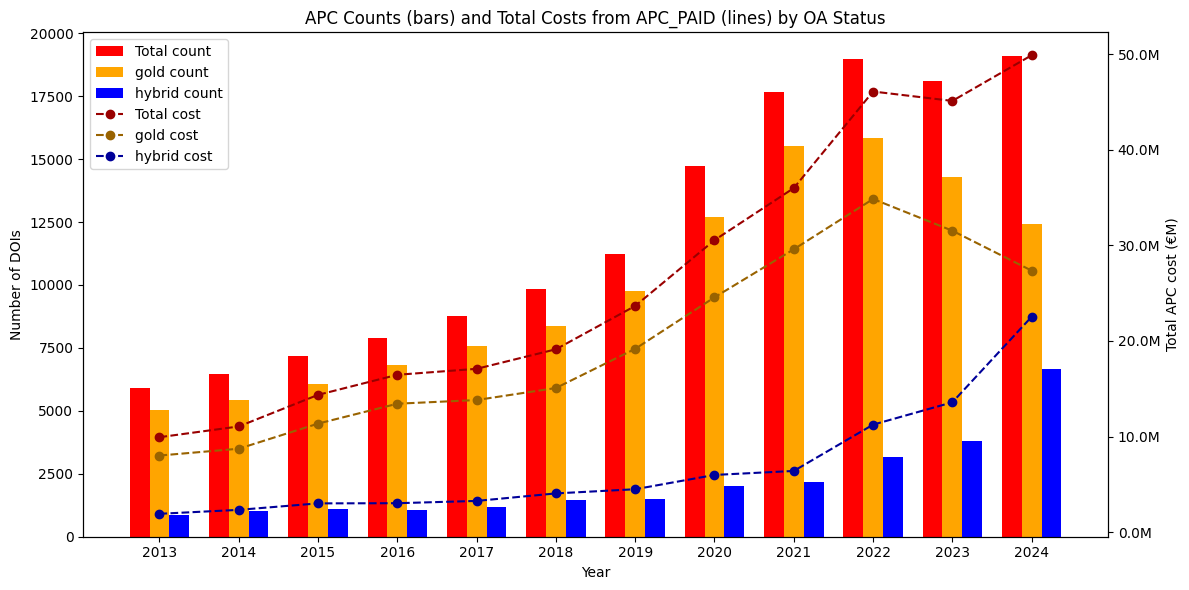

In [23]:
df_inclusive_paid_tmp_0 = df_inclusive_paid.copy()
df_inclusive_paid_tmp_0['fr_cost'] = df_inclusive_paid_tmp_0.value_usd_to_eur

df_inclusive_paid_tmp_0_oa_gold_hyb = df_inclusive_paid_tmp_0[df_inclusive_paid_tmp_0.oa_status.isin(['hybrid', 'gold'])].reset_index(drop = True)
status = df_inclusive_paid_tmp_0_oa_gold_hyb.groupby(['publication_year', 'oa_status']).agg({'doi':'count', 'fr_cost': 'sum'})
total = df_inclusive_paid_tmp_0_oa_gold_hyb.groupby(['publication_year']).agg({'doi':'count', 'fr_cost': 'sum'})
total['oa_status'] = 'Total'
total = total.set_index('oa_status', append=True)
df_data = pd.concat([status, total]).sort_index()

bar_width = 0.25
years = sorted(df_inclusive_paid_tmp_0_oa_gold_hyb.publication_year.unique())
x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(12,6))

colors = {'gold':'orange', 'hybrid':'blue', 'Total':'red'}

# Function to darken a color
def darken_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return (c[0]*amount, c[1]*amount, c[2]*amount)

# Plot bars for counts
count_df = df_data['doi'].unstack('oa_status').fillna(0)
for i, col in enumerate(count_df.columns):
    ax1.bar(x + i*bar_width, count_df[col], width=bar_width, color=colors.get(col,'grey'), label=f"{col} count")

ax1.set_ylabel('Number of DOIs')
ax1.set_xlabel('Year')
ax1.set_xticks(x + bar_width)  # center x-ticks under grouped bars
ax1.set_xticklabels(years)

# Right axis for cost lines
cost_df = df_data['fr_cost'].unstack('oa_status').fillna(0)
ax2 = ax1.twinx()
for col in cost_df.columns:
    dark_color = darken_color(colors.get(col,'grey'))
    ax2.plot(x + bar_width, cost_df[col], color=dark_color, marker='o', linestyle='--', label=f"{col} cost")

# Format y-axis in millions
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*1e-6:.1f}M'))

ax2.set_ylabel('Total APC cost (€M)')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('APC Counts (bars) and Total Costs from APC_PAID (lines) by OA Status')
plt.tight_layout()
plt.show()

In [24]:
cost_df

oa_status,Total,gold,hybrid
publication_year,,,
2013,9.930659e+06,8.012366e+06,1.918293e+06
2014,1.105623e+07,8.725867e+06,2.330365e+06
2015,1.436135e+07,1.135295e+07,3.008403e+06
2016,1.646030e+07,1.343446e+07,3.025842e+06
2017,1.708438e+07,1.381901e+07,3.265369e+06
2018,1.912933e+07,1.507758e+07,4.051752e+06
2019,2.366385e+07,1.917601e+07,4.487845e+06
2020,3.054617e+07,2.456327e+07,5.982903e+06
2021,3.599240e+07,2.959106e+07,6.401340e+06


**Detect outliers**

In [25]:
df_open_apc['log_price'] = np.log1p(df_open_apc['euro'])
journal_stats = (df_open_apc.groupby('issn_l')['log_price'].agg(median = 'median', mad = lambda x: np.median(np.abs(x - np.median(x))), count = 'size').reset_index())

df_open_apc = df_open_apc.merge(journal_stats, on = 'issn_l', how = 'left')
df_open_apc['journal_mad_score'] = np.abs(df_open_apc['log_price'] - df_open_apc['median']) / df_open_apc['mad']

df_open_apc['is_outlier'] = ((df_open_apc['count'] >= 10) & (df_open_apc['journal_mad_score'] > 4))

df_open_apc = df_open_apc[df_open_apc.is_outlier == False].reset_index(drop = True)
print(len(df_open_apc[df_open_apc.is_outlier == False]))
df_open_apc

241837


,doi,euro,issn_l,period,institution,log_price,median,mad,count,journal_mad_score,is_outlier
0,10.3389/fpsyg.2013.00318,960.00,1664-1078,2013,Bamberg U,6.867974,7.601002,0.200280,3332.0,3.660008,False
1,10.3389/fpsyg.2013.00406,960.00,1664-1078,2013,Bamberg U,6.867974,7.601002,0.200280,3332.0,3.660008,False
2,10.3389/fpsyg.2013.00453,960.00,1664-1078,2013,Bamberg U,6.867974,7.601002,0.200280,3332.0,3.660008,False
3,10.6000/1929-4409.2013.02.32,182.00,1929-4409,2013,Bamberg U,5.209486,5.744060,0.534574,3.0,1.000000,False
4,10.1068/i0605,405.79,2041-6695,2013,Bamberg U,6.008297,6.267513,0.314498,78.0,0.824223,False
...,...,...,...,...,...,...,...,...,...,...,...
241832,10.3390/mti9070072,1928.90,2414-4088,2025,University of Turku,7.565223,7.258743,0.263051,33.0,1.165098,False
241833,10.1098/rsos.250490,1581.30,2054-5703,2025,University of Turku,7.366635,7.159447,0.172074,228.0,1.204059,False
241834,10.3389/frcha.2025.1637011,2117.31,2813-4540,2025,University of Turku,7.658374,7.707267,0.042535,4.0,1.149487,False
241835,10.1093/femsec/fiaf081,2298.71,0168-6496,2025,University of Turku,7.740538,7.934986,0.103853,41.0,1.872332,False


**Median method**

In [26]:
threshold = 3
grouped = df_open_apc.groupby(['issn_l', 'period'])['euro'].agg(median = 'median', count = 'size')
grouped = grouped[grouped['count'] > threshold].reset_index().drop(columns = 'count')
print(len(df_open_apc[df_open_apc.issn_l.isin(grouped.issn_l)]), grouped.issn_l.nunique())

df_inclusive_paid_tmp_1 = df_inclusive_paid.merge(grouped, left_on = ['issn_l', 'publication_year'], right_on = ['issn_l', 'period'], how = 'left').drop(columns = 'period')
print(len(df_inclusive_paid_tmp_1[(df_inclusive_paid_tmp_1['median'].notna()) & (df_inclusive_paid.euro.isna())  & (df_inclusive_paid.APC_Accounting_Value.isna())]))
df_inclusive_paid_tmp_1

216204 2832
70631


,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,priority,First_Last_FR,First_pct,Last_pct,Middle_pct,publisher,value_usd,value_usd_to_eur,euro,median
0,10.1016/j.rse.2012.12.008,2013,en,0034-4257,hybrid,"{'value': 4070, 'currency': 'USD', 'value_usd'...","[True, False, False, False, False, False, Fals...","[['CN', 'FR'], ['CN'], ['CN'], ['CN'], ['CN'],...",False,True,...,3.0,NaN,NaN,NaN,NaN,Elsevier BV,4070,3072.706520,NaN,NaN
1,10.5194/bg-10-6225-2013,2013,en,1726-4170,gold,"{'value': 1510, 'currency': 'EUR', 'value_usd'...","[True, False, True, True, False, True, True, T...","[['FR'], ['FR'], ['FR'], ['US'], ['US'], ['FR'...",False,True,...,3.0,NaN,NaN,NaN,NaN,Copernicus GmbH,1628,1229.082608,NaN,1236.10
2,10.1016/j.mattod.2013.06.004,2013,en,1369-7021,hybrid,"{'value': 5300, 'currency': 'USD', 'value_usd'...",[True],[['FR']],True,True,...,3.0,NaN,NaN,NaN,NaN,Elsevier BV,5300,4001.313159,NaN,NaN
3,10.1371/journal.pmed.1001453,2013,en,1549-1277,gold,"{'value': 5300, 'currency': 'USD', 'value_usd'...","[True, True, True, True, True, True, True, Tru...","[['FR'], ['FR'], ['FR'], ['FR'], ['FR'], ['FR'...",False,True,...,3.0,NaN,NaN,NaN,NaN,Public Library of Science (PLoS),5300,4001.313159,NaN,NaN
4,10.1186/1754-6834-6-41,2013,en,1754-6834,gold,"{'value': 1990, 'currency': 'GBP', 'value_usd'...","[True, False, False, False, False]","[['FR'], ['FR'], ['FR'], ['FR'], ['FR']]",False,True,...,3.0,NaN,NaN,NaN,NaN,Springer Science and Business Media LLC,2440,1842.113983,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147292,10.1093/bioadv/vbaf090,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[['FR'], ['FR'], ['FR'], ['FR']]",NaN,False,...,NaN,True,0.555556,0.444444,0.0,Oxford University Press (OUP),2164,1996.966369,NaN,2388.47
147293,10.1210/jendso/bvae163.2303,2024,en,2472-1972,gold,"{'value': 2822, 'currency': 'USD', 'value_usd'...","[False, False, False, False, False, False, Fal...","[['FR'], ['FR'], ['FR'], ['FR'], ['FR'], ['FR'...",NaN,False,...,NaN,True,0.555556,0.444444,0.0,The Endocrine Society,2822,2604.177030,NaN,NaN
147294,10.1093/bioadv/vbaf128,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[['FR'], ['FR'], ['FR'], ['FR']]",NaN,False,...,NaN,True,0.555556,0.444444,0.0,Oxford University Press (OUP),2164,1996.966369,NaN,2388.47
147295,10.1093/bioadv/vbaf096,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[['FR'], ['CM'], ['FR'], ['FR']]",NaN,False,...,NaN,True,0.555556,0.444444,0.0,Oxford University Press (OUP),2164,1996.966369,NaN,2388.47


In [27]:
priority_result = df_inclusive_paid_tmp_1.apply(priority, axis=1, result_type='expand')
df_inclusive_paid_tmp_1[['price_var', 'priority']] = priority_result
df_inclusive_paid_tmp_1['countries'] = df_inclusive_paid_tmp_1['countries'].apply(safe_literal_eval)
df_inclusive_paid_tmp_1['french_position'] = df_inclusive_paid_tmp_1['countries'].apply(lambda lst: [i for i, inner in enumerate(lst) if 'FR' in inner])
df_inclusive_paid_tmp_1['len'] = df_inclusive_paid_tmp_1['countries'].apply(lambda x: len(x))
df_inclusive_paid_tmp_1['fr_cost'] = df_inclusive_paid_tmp_1.apply(lambda x: x['price_var'] if pd.isna(x['First_Last_FR']) else price(x), axis = 1)
df_inclusive_paid_tmp_1.to_csv('../data/processed/costs.csv')
df_inclusive_paid_tmp_1

,doi,publication_year,language,issn_l,oa_status,apc_paid,corresponding,countries,has_fr_corresponding,BSO,...,Middle_pct,publisher,value_usd,value_usd_to_eur,euro,median,price_var,french_position,len,fr_cost
0,10.1016/j.rse.2012.12.008,2013,en,0034-4257,hybrid,"{'value': 4070, 'currency': 'USD', 'value_usd'...","[True, False, False, False, False, False, Fals...","[[CN, FR], [CN], [CN], [CN], [CN], [US], [PT],...",False,True,...,NaN,Elsevier BV,4070,3072.706520,NaN,NaN,3072.706520,[0],8,3072.706520
1,10.5194/bg-10-6225-2013,2013,en,1726-4170,gold,"{'value': 1510, 'currency': 'EUR', 'value_usd'...","[True, False, True, True, False, True, True, T...","[[FR], [FR], [FR], [US], [US], [FR], [GB], [NO...",False,True,...,NaN,Copernicus GmbH,1628,1229.082608,NaN,1236.10,1236.100000,"[0, 1, 2, 5, 9]",12,1236.100000
2,10.1016/j.mattod.2013.06.004,2013,en,1369-7021,hybrid,"{'value': 5300, 'currency': 'USD', 'value_usd'...",[True],[[FR]],True,True,...,NaN,Elsevier BV,5300,4001.313159,NaN,NaN,4001.313159,[0],1,4001.313159
3,10.1371/journal.pmed.1001453,2013,en,1549-1277,gold,"{'value': 5300, 'currency': 'USD', 'value_usd'...","[True, True, True, True, True, True, True, Tru...","[[FR], [FR], [FR], [FR], [FR], [FR], [FR], [FR...",False,True,...,NaN,Public Library of Science (PLoS),5300,4001.313159,NaN,NaN,4001.313159,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14,...",24,4001.313159
4,10.1186/1754-6834-6-41,2013,en,1754-6834,gold,"{'value': 1990, 'currency': 'GBP', 'value_usd'...","[True, False, False, False, False]","[[FR], [FR], [FR], [FR], [FR]]",False,True,...,NaN,Springer Science and Business Media LLC,2440,1842.113983,NaN,NaN,1842.113983,"[0, 1, 2, 3, 4]",5,1842.113983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147292,10.1093/bioadv/vbaf090,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[[FR], [FR], [FR], [FR]]",NaN,False,...,0.0,Oxford University Press (OUP),2164,1996.966369,NaN,2388.47,2388.470000,"[0, 1, 2, 3]",4,1326.927778
147293,10.1210/jendso/bvae163.2303,2024,en,2472-1972,gold,"{'value': 2822, 'currency': 'USD', 'value_usd'...","[False, False, False, False, False, False, Fal...","[[FR], [FR], [FR], [FR], [FR], [FR], [FR], [FR...",NaN,False,...,0.0,The Endocrine Society,2822,2604.177030,NaN,NaN,2604.177030,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15]",16,1446.765017
147294,10.1093/bioadv/vbaf128,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[[FR], [FR], [FR], [FR]]",NaN,False,...,0.0,Oxford University Press (OUP),2164,1996.966369,NaN,2388.47,2388.470000,"[0, 1, 2, 3]",4,1326.927778
147295,10.1093/bioadv/vbaf096,2024,en,2635-0041,gold,"{'value': 1765, 'currency': 'GBP', 'value_usd'...","[False, False, False, False]","[[FR], [CM], [FR], [FR]]",NaN,False,...,0.0,Oxford University Press (OUP),2164,1996.966369,NaN,2388.47,2388.470000,"[0, 2, 3]",4,1326.927778


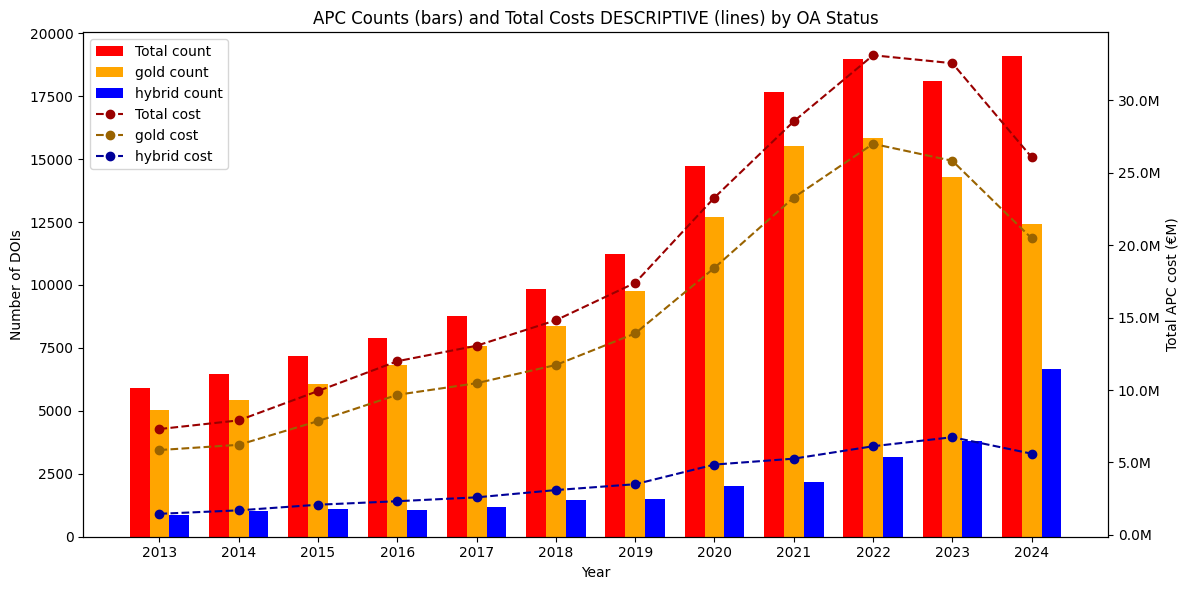

In [28]:
df_inclusive_paid_tmp_1_oa_gold_hyb = df_inclusive_paid_tmp_1[df_inclusive_paid_tmp_1.oa_status.isin(['hybrid', 'gold'])].reset_index(drop = True)
status = df_inclusive_paid_tmp_1_oa_gold_hyb.groupby(['publication_year', 'oa_status']).agg({'doi':'count', 'fr_cost': 'sum'})
total = df_inclusive_paid_tmp_1_oa_gold_hyb.groupby(['publication_year']).agg({'doi':'count', 'fr_cost': 'sum'})
total['oa_status'] = 'Total'
total = total.set_index('oa_status', append=True)
df_data = pd.concat([status, total]).sort_index()

bar_width = 0.25
years = sorted(df_inclusive_paid_tmp_1_oa_gold_hyb.publication_year.unique())
x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(12,6))

colors = {'gold':'orange', 'hybrid':'blue', 'Total':'red'}

# Function to darken a color
def darken_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return (c[0]*amount, c[1]*amount, c[2]*amount)

# Plot bars for counts
count_df = df_data['doi'].unstack('oa_status').fillna(0)
for i, col in enumerate(count_df.columns):
    ax1.bar(x + i*bar_width, count_df[col], width=bar_width, color=colors.get(col,'grey'), label=f"{col} count")

ax1.set_ylabel('Number of DOIs')
ax1.set_xlabel('Year')
ax1.set_xticks(x + bar_width)  # center x-ticks under grouped bars
ax1.set_xticklabels(years)

# Right axis for cost lines
cost_df = df_data['fr_cost'].unstack('oa_status').fillna(0)
ax2 = ax1.twinx()
for col in cost_df.columns:
    dark_color = darken_color(colors.get(col,'grey'))
    ax2.plot(x + bar_width, cost_df[col], color=dark_color, marker='o', linestyle='--', label=f"{col} cost")

# Format y-axis in millions
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*1e-6:.1f}M'))

ax2.set_ylabel('Total APC cost (€M)')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('APC Counts (bars) and Total Costs DESCRIPTIVE (lines) by OA Status')
plt.tight_layout()
plt.show()

In [29]:
cost_df

oa_status,Total,gold,hybrid
publication_year,,,
2013,7.305084e+06,5.853956e+06,1.451129e+06
2014,7.903812e+06,6.214666e+06,1.689145e+06
2015,9.930974e+06,7.852732e+06,2.078242e+06
2016,1.199010e+07,9.669653e+06,2.320446e+06
2017,1.305846e+07,1.047164e+07,2.586820e+06
2018,1.482000e+07,1.172937e+07,3.090636e+06
2019,1.740327e+07,1.390878e+07,3.494489e+06
2020,2.329506e+07,1.844354e+07,4.851521e+06
2021,2.855581e+07,2.329626e+07,5.259552e+06


### Publisher stacked

In [ ]:
# df_inclusive = pd.read_csv('../data/processed/main_dataset.csv')
df_inclusive['doi_prefix'] = df_inclusive.doi.apply(lambda x: x.split('/')[0])

publisher = pd.read_csv('../data/processed/publisher_doi_full.csv')

df_publisher = df_inclusive.merge(publisher, on = 'doi_prefix', how = 'left')

# THERE ARE 10924 DOIS (0.94% OF THEM) WITHOUT LINK

df_group = pd.read_csv('../data/processed/publisher_group.csv', header = None)[1::]
df_group.columns = df_group.iloc[0]
df_group = df_group.iloc[1:].reset_index(drop=True)[['publisher_clean', 'publisher_group', 'group_start_date']]
pub_dict = df_group.set_index('publisher_clean')['publisher_group'].to_dict()
year_dict = df_group.set_index('publisher_clean')['group_start_date'].astype(int).to_dict()
mask = (df_publisher['publisher'].isin(pub_dict) & df_publisher['publisher'].isin(year_dict) & (df_publisher['publication_year'] >= df_publisher['publisher'].map(year_dict)))
df_publisher.loc[mask, 'publisher'] = df_publisher.loc[mask, 'publisher'].map(pub_dict)

top_publishers = list(df_publisher.groupby('publisher').count().sort_values('doi', ascending = False)[0:10].index)
years = range(2013, 2025)
df_per = pd.DataFrame(index = top_publishers, columns = years)
for year in years: 
    df_publisher_year = df_publisher[df_publisher.publication_year == year]  
    for publisher in top_publishers:
        df_publisher_year_publisher = df_publisher_year[df_publisher_year.publisher == publisher]            
        df_per.at[publisher, year] = df_publisher_year_publisher.doi.nunique() / df_publisher_year.doi.nunique()

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(df_per.columns.astype(int), df_per.values.astype(float) * 100, labels = df_per.index)
ax.set_xticks(np.arange(years[0], years[-1] + 1))
ax.set_xticklabels(np.arange(years[0], years[-1] + 1), rotation = 45)
ax.set_yticks(np.arange(0, 80, 10))
ax.set_yticklabels(np.arange(0, 80, 10))
ax.set_xlim(years[0], years[-1])
ax.set_ylim(0, 75)
ax.set_ylabel('Volume (%)', fontsize = 16)  
ax.set_xlabel('Time (y)', fontsize = 16)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))


KeyError: 'publisher'

### Costs subscriptions

In [32]:
df = pd.read_csv('../data/external/fr-esr-ere-enquete-ressources-electroniques.csv', sep = ';', encoding = 'utf-8', engine = 'python', quotechar = '"', on_bad_lines = 'warn')
df

,Millesime,id Paysage,Etablissement,nom_court,sigle,Editeur,Identifiant éditeur,Produit,Identifiant produit,Négocié,...,identifiant_idref,identifiant_wikidata,identifiant_ror,Statut juridique court,Région,Académie,Département,dep_id,aca_id,reg_id
0,2020,t6Cq5,Université de Lorraine,NaN,UL,Mathematical Sciences publishers,367.0,Mathematical Sciences publishers (MSP) - Revues,367.0,Non,...,157040569,Q4173330,04vfs2w97,EPSCP,Grand Est,Nancy-Metz,Meurthe-et-Moselle,D054,A12,R44
1,2021,2Nnrv,Institut supérieur de l'aéronautique et de l'e...,ISAE-SUPAERO,NaN,American Institute of Physics (AIP),340.0,American Institute of Physics (AIP) - Revues,340.0,Oui,...,026523493,Q155446,04gyj6s21,EPSCP,Occitanie,Toulouse,Haute-Garonne,D031,A16,R76
2,2023,K6jgY,Télécom Paris,NaN,NaN,Association for Computing Machinery (ACM) / TS...,NaN,ACM Digital Library,5.0,Oui,...,026375273,Q2311820,01naq7912,Sans personnalité juridique - secteur public,Île-de-France,Versailles,Essonne,D091,A25,R11
3,2021,VaJ52,Muséum national d'histoire naturelle,NaN,MNHN,Springer Nature,151.0,Springer Nature - eBooks STM collection - Eart...,1429.0,Oui,...,026394944,Q838691,03wkt5x30,EPSCP,Île-de-France,Paris,Paris,D075,A01,R11
4,2022,U8a0v,Université de Lille,NaN,NaN,American Physical Society (APS),341.0,American Physical Society (APS) - Revues,341.0,Oui,...,259265152,NaN,02kzqn938,EPSCP,Hauts-de-France,Lille,Nord,D059,A09,R32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51709,2021,8618D,École normale supérieure PSL,NaN,ENS PSL,University of California Press,518.0,Thesaurus Linguae Graecae (TLG) Online,518.0,Non,...,031738419,Q83259,05a0dhs15,EPSCP,Île-de-France,Paris,Paris,D075,A01,R11
51710,2022,56aH3,École nationale des travaux publics de l'État,NaN,ENTPE,American Institute of Physics (AIP),340.0,American Institute of Physics (AIP) - Revues (...,514.0,Non,...,027941426,Q3578157,05r0ccb59,EPSCP,Auvergne-Rhône-Alpes,Lyon,Rhône,D069,A10,R84
51711,2019,gIvzd,Institut national de la recherche agronomique,NaN,INRA,American Association of immunologists,561.0,The Journal of Immunology,561.0,Non,...,02638809X,Q1665106,01x3gbx83,EPA,Île-de-France,Paris,Paris,D075,A01,R11
51712,2023,n2X5f,Centre national de la recherche scientifique,CNRS,CNRS,Cold Spring Harbour laboratory Press,375.0,Cold Spring Harbour Laboratory - Revues titre ...,375.0,Non,...,02636817X,Q280413,02feahw73,EPA,Île-de-France,Paris,Paris,D075,A01,R11


In [33]:
df.columns

Index(['Millesime', 'id Paysage', 'Etablissement', 'nom_court', 'sigle',
       'Editeur', 'Identifiant éditeur', 'Produit', 'Identifiant produit',
       'Négocié', 'Montant (en € HT)', 'uai', 'siret', 'identifiant_idref',
       'identifiant_wikidata', 'identifiant_ror', 'Statut juridique court',
       'Région', 'Académie', 'Département', 'dep_id', 'aca_id', 'reg_id'],
      dtype='object')